In [3]:
import logging

# Configure logging
logging.basicConfig(
    filename='/kaggle/working/training.log',  # log file saved in Kaggle output
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logging.info("🔥 Starting the Multi-Task Training Engine...")

In [4]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

# --- 1. THE 2-TIER MEDICAL MAPPER ---
def get_two_tier_labels(raw_label):
    label = str(raw_label).lower()
    
    # 1. MALIGNANT
    if 'melanoma' in label: return 'Malignant', 'Melanoma'
    if 'basal cell' in label or 'bcc' in label: return 'Malignant', 'Basal Cell Carcinoma'
    if 'actinic' in label: return 'Malignant', 'Actinic Keratosis'
    if any(x in label for x in ['malignant', 'carcinoma', 'scc']): return 'Malignant', 'Other Carcinoma'
    
    # 2. BENIGN
    if 'nevi' in label or 'moles' in label or label == 'benign': return 'Benign', 'Nevi (Mole)'
    if 'seborrheic' in label: return 'Benign', 'Seborrheic Keratosis'
    if 'benign tumors' in label: return 'Benign', 'Other Benign Tumor'
    
    # 3. ACNE & ROSACEA
    if 'rosacea' in label: return 'Acne_Rosacea', 'Rosacea'
    if 'acne' in label: return 'Acne_Rosacea', 'Acne Vulgaris'
    
    # 4. INFLAMMATORY
    if 'eczema' in label or 'atopic' in label: return 'Inflammatory', 'Eczema'
    if 'psoriasis' in label or 'lichen' in label: return 'Inflammatory', 'Psoriasis'
    if 'poison' in label or 'contact' in label: return 'Inflammatory', 'Contact Dermatitis'
    if 'urticaria' in label or 'hives' in label: return 'Inflammatory', 'Urticaria (Hives)'
    if 'vasculitis' in label: return 'Inflammatory', 'Vasculitis'
    
    # 5. INFECTIOUS
    if 'bacterial' in label or 'cellulitis' in label or 'impetigo' in label: return 'Infectious', 'Bacterial Infection'
    if 'fungal' in label or 'tinea' in label or 'ringworm' in label: return 'Infectious', 'Fungal Infection'
    if 'viral' in label or 'herpes' in label or 'warts' in label or 'hpv' in label or 'molluscum' in label: return 'Infectious', 'Viral Infection'
    if 'scabies' in label or 'lyme' in label or 'bites' in label: return 'Infectious', 'Parasitic/Bites'
    
    # 6. PIGMENTARY
    if 'vitiligo' in label or 'pigment' in label: return 'Pigmentary', 'Pigmentation Disorder'
    
    # 7. HAIR & NAIL
    if 'hair' in label or 'alopecia' in label: return 'Hair_Nail', 'Alopecia / Hair Loss'
    if 'nail' in label: return 'Hair_Nail', 'Nail Disease'
    
    # 8. SYSTEMIC & OTHER
    if 'lupus' in label: return 'Systemic_Other', 'Lupus'
    if 'bullous' in label: return 'Systemic_Other', 'Bullous Disease'
    if 'drug' in label or 'exanthem' in label: return 'Systemic_Other', 'Drug Eruption'
    
    # Fallback
    return 'Systemic_Other', 'Unclassified / Other'

master_data = []

# --- 2. PROCESS ISIC 2024 ---
print("Processing ISIC 2024...")
isic_csv_path = '/kaggle/input/isic-2024-challenge/train-metadata.csv'
isic_img_dir = '/kaggle/input/isic-2024-challenge/train-image/image/'

if os.path.exists(isic_csv_path):
    isic_df = pd.read_csv(isic_csv_path, low_memory=False)
    
    isic_mal = isic_df[isic_df['target'] == 1]
    isic_ben = isic_df[isic_df['target'] == 0].sample(10000, random_state=42)
    isic_balanced = pd.concat([isic_mal, isic_ben])
    
    for _, row in tqdm(isic_balanced.iterrows(), total=len(isic_balanced)):
        img_path = os.path.join(isic_img_dir, f"{row['isic_id']}.jpg")
        if os.path.exists(img_path):
            # Map ISIC based on target
            sup_c, sub_c = ('Malignant', 'Melanoma') if row['target'] == 1 else ('Benign', 'Nevi (Mole)')
            master_data.append({
                'image_path': img_path,
                'original_label': 'Malignant' if row['target'] == 1 else 'Benign',
                'super_class': sup_c,
                'sub_class': sub_c,
                'source': 'ISIC_2024'
            })

# --- 3. PROCESS DERMNET ---
print("\nProcessing DermNet...")
dermnet_dir = '/kaggle/input/datasets/shubhamgoel27/dermnet/train'

if os.path.exists(dermnet_dir):
    for folder_name in tqdm(os.listdir(dermnet_dir)):
        folder_path = os.path.join(dermnet_dir, folder_name)
        if os.path.isdir(folder_path):
            sup_c, sub_c = get_two_tier_labels(folder_name)
            for img_name in os.listdir(folder_path):
                img_path = os.path.join(folder_path, img_name)
                if img_path.lower().endswith(('.jpg', '.jpeg', '.png')):
                    master_data.append({
                        'image_path': img_path,
                        'original_label': folder_name,
                        'super_class': sup_c,
                        'sub_class': sub_c,
                        'source': 'DermNet'
                    })

# --- 4. PROCESS FITZPATRICK 17K ---
print("\nProcessing Fitzpatrick 17k...")
fitz_img_dir = '/kaggle/input/fitzpatrick17k-original/finalfitz17k'
fitz_csv_url = 'https://raw.githubusercontent.com/mattgroh/fitzpatrick17k/main/fitzpatrick17k.csv'

try:
    fitz_df = pd.read_csv(fitz_csv_url)
    if os.path.exists(fitz_img_dir):
        for _, row in tqdm(fitz_df.iterrows(), total=len(fitz_df)):
            img_path = os.path.join(fitz_img_dir, f"{row['md5hash']}.jpg")
            if os.path.exists(img_path):
                sup_c, sub_c = get_two_tier_labels(row['label'])
                master_data.append({
                    'image_path': img_path,
                    'original_label': row['label'],
                    'super_class': sup_c,
                    'sub_class': sub_c,
                    'source': 'Fitzpatrick17k'
                })
except Exception as e:
    print(f"Could not load Fitzpatrick CSV from web: {e}")

# --- 5. FINALIZE AND EXPORT ---
df_master = pd.DataFrame(master_data)
df_master = df_master.drop_duplicates(subset=['image_path']).reset_index(drop=True)

print("\n=== REAL-WORLD DATASET CREATED ===")
print(f"Total Images: {len(df_master)}")
print("\nTop 10 Sub-Classes (Specific Diseases):")
print(df_master['sub_class'].value_counts().head(10))

# Save the new version
output_file = '/kaggle/working/master_skin_dataset_v2.csv'
df_master.to_csv(output_file, index=False)
print(f"\nSaved successfully to: {output_file}")

Processing ISIC 2024...


100%|██████████| 10393/10393 [01:46<00:00, 97.61it/s] 



Processing DermNet...


100%|██████████| 23/23 [00:00<00:00, 41.50it/s]



Processing Fitzpatrick 17k...


100%|██████████| 16577/16577 [01:54<00:00, 144.39it/s]



=== REAL-WORLD DATASET CREATED ===
Total Images: 42524

Top 10 Sub-Classes (Specific Diseases):
sub_class
Unclassified / Other    10662
Nevi (Mole)             10000
Psoriasis                2849
Eczema                   2011
Basal Cell Carcinoma     1745
Seborrheic Keratosis     1566
Viral Infection          1558
Melanoma                 1346
Fungal Infection         1300
Nail Disease             1040
Name: count, dtype: int64

Saved successfully to: /kaggle/working/master_skin_dataset_v2.csv


In [5]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

def get_two_tier_labels(raw_label):
    label = str(raw_label).lower()
    
    # 1. MALIGNANT
    if 'melanoma' in label: return 'Malignant', 'Melanoma'
    if 'basal cell' in label or 'bcc' in label: return 'Malignant', 'Basal Cell Carcinoma'
    if 'actinic' in label: return 'Malignant', 'Actinic Keratosis'
    if any(x in label for x in ['malignant', 'carcinoma', 'scc']): return 'Malignant', 'Other Carcinoma'
    
    # 2. BENIGN
    if 'nevi' in label or 'moles' in label or label == 'benign' or 'nevus' in label: return 'Benign', 'Nevi (Mole)'
    if 'seborrheic' in label: return 'Benign', 'Seborrheic Keratosis'
    if 'benign tumors' in label: return 'Benign', 'Other Benign Tumor'
    
    # 3. ACNE & ROSACEA
    if 'rosacea' in label: return 'Acne_Rosacea', 'Rosacea'
    if 'acne' in label: return 'Acne_Rosacea', 'Acne Vulgaris'
    
    # 4. INFLAMMATORY
    if 'eczema' in label or 'atopic' in label: return 'Inflammatory', 'Eczema'
    if 'psoriasis' in label or 'lichen' in label: return 'Inflammatory', 'Psoriasis'
    if 'poison' in label or 'contact' in label: return 'Inflammatory', 'Contact Dermatitis'
    if 'urticaria' in label or 'hives' in label: return 'Inflammatory', 'Urticaria (Hives)'
    if 'vasculitis' in label: return 'Inflammatory', 'Vasculitis'
    if 'dermatitis' in label: return 'Inflammatory', 'Other Dermatitis'
    
    # 5. INFECTIOUS
    if 'bacterial' in label or 'cellulitis' in label or 'impetigo' in label: return 'Infectious', 'Bacterial Infection'
    if 'fungal' in label or 'tinea' in label or 'ringworm' in label or 'candidiasis' in label: return 'Infectious', 'Fungal Infection'
    if 'viral' in label or 'herpes' in label or 'warts' in label or 'hpv' in label or 'molluscum' in label: return 'Infectious', 'Viral Infection'
    if 'scabies' in label or 'lyme' in label or 'bites' in label or 'infestations' in label: return 'Infectious', 'Parasitic/Bites'
    
    # 6. PIGMENTARY
    if 'vitiligo' in label or 'pigment' in label: return 'Pigmentary', 'Pigmentation Disorder'
    
    # 7. HAIR & NAIL
    if 'hair' in label or 'alopecia' in label: return 'Hair_Nail', 'Alopecia / Hair Loss'
    if 'nail' in label: return 'Hair_Nail', 'Nail Disease'
    
    # 8. SYSTEMIC & OTHER
    if 'lupus' in label: return 'Systemic_Other', 'Lupus'
    if 'bullous' in label: return 'Systemic_Other', 'Bullous Disease'
    if 'drug' in label or 'exanthem' in label: return 'Systemic_Other', 'Drug Eruption'
    if 'vascular' in label: return 'Systemic_Other', 'Vascular Tumor/Lesion'
    if 'systemic' in label: return 'Systemic_Other', 'Systemic Disease'
    
    # Fallback
    return 'Systemic_Other', 'Unclassified / Other'

master_data = []

# --- 2. PROCESS ISIC 2024 (Balanced) ---
print("Processing ISIC 2024...")
isic_csv_path = '/kaggle/input/isic-2024-challenge/train-metadata.csv'
isic_img_dir = '/kaggle/input/isic-2024-challenge/train-image/image/'

if os.path.exists(isic_csv_path):
    isic_df = pd.read_csv(isic_csv_path, low_memory=False)
    
    isic_mal = isic_df[isic_df['target'] == 1]
    isic_ben = isic_df[isic_df['target'] == 0].sample(10000, random_state=42)
    isic_balanced = pd.concat([isic_mal, isic_ben])
    
    for _, row in tqdm(isic_balanced.iterrows(), total=len(isic_balanced)):
        img_path = os.path.join(isic_img_dir, f"{row['isic_id']}.jpg")
        if os.path.exists(img_path):
            # Extract specific disease from ISIC if available, else use target
            diag = row.get('iddx_1', 'unknown')
            if pd.isna(diag) or diag == 'unknown':
                super_c, sub_c = ('Malignant', 'Unclassified Malignant') if row['target'] == 1 else ('Benign', 'Unclassified Benign')
            else:
                super_c, sub_c = get_two_tier_labels(diag)
                
            master_data.append({
                'image_path': img_path,
                'super_class': super_c,
                'sub_class': sub_c,
                'source': 'ISIC_2024'
            })

# --- 3. PROCESS DERMNET ---
print("\nProcessing DermNet...")
dermnet_dir = '/kaggle/input/datasets/shubhamgoel27/dermnet/train'

if os.path.exists(dermnet_dir):
    for folder_name in tqdm(os.listdir(dermnet_dir)):
        folder_path = os.path.join(dermnet_dir, folder_name)
        if os.path.isdir(folder_path):
            # NEW: Getting both tiers!
            super_c, sub_c = get_two_tier_labels(folder_name)
            for img_name in os.listdir(folder_path):
                img_path = os.path.join(folder_path, img_name)
                if img_path.lower().endswith(('.jpg', '.jpeg', '.png')):
                    master_data.append({
                        'image_path': img_path,
                        'super_class': super_c,
                        'sub_class': sub_c,
                        'source': 'DermNet'
                    })

# --- 4. PROCESS FITZPATRICK 17K ---
print("\nProcessing Fitzpatrick 17k...")
fitz_img_dir = '/kaggle/input/fitzpatrick17k-original/finalfitz17k'
fitz_csv_url = 'https://raw.githubusercontent.com/mattgroh/fitzpatrick17k/main/fitzpatrick17k.csv'

try:
    fitz_df = pd.read_csv(fitz_csv_url)
    if os.path.exists(fitz_img_dir):
        for _, row in tqdm(fitz_df.iterrows(), total=len(fitz_df)):
            img_path = os.path.join(fitz_img_dir, f"{row['md5hash']}.jpg")
            if os.path.exists(img_path):
                # NEW: Getting both tiers!
                super_c, sub_c = get_two_tier_labels(row['label'])
                master_data.append({
                    'image_path': img_path,
                    'super_class': super_c,
                    'sub_class': sub_c,
                    'source': 'Fitzpatrick17k'
                })
except Exception as e:
    print(f"Could not load Fitzpatrick CSV: {e}")

# --- 5. FINALIZE AND EXPORT ---
df_master = pd.DataFrame(master_data)
df_master = df_master.drop_duplicates(subset=['image_path']).reset_index(drop=True)

print("\n=== TWO-TIER MASTER DATASET CREATED ===")
print(f"Total Valid Images: {len(df_master)}")

print("\n--- Tier 1: SUPER-CLASS Distribution ---")
print(df_master['super_class'].value_counts())

print("\n--- Tier 2: SUB-CLASS Distribution (Top 15 Diseases) ---")
print(df_master['sub_class'].value_counts().head(15))

# Save the updated CSV
output_file = '/kaggle/working/master_skin_dataset_twotier.csv'
df_master.to_csv(output_file, index=False)
print(f"\nSaved successfully to: {output_file}")

Processing ISIC 2024...


100%|██████████| 10393/10393 [00:23<00:00, 439.54it/s] 



Processing DermNet...


100%|██████████| 23/23 [00:00<00:00, 450.70it/s]



Processing Fitzpatrick 17k...


100%|██████████| 16577/16577 [00:14<00:00, 1146.81it/s]



=== TWO-TIER MASTER DATASET CREATED ===
Total Valid Images: 42524

--- Tier 1: SUPER-CLASS Distribution ---
super_class
Benign            12049
Systemic_Other    11884
Inflammatory       6729
Malignant          4090
Infectious         4045
Acne_Rosacea       1460
Hair_Nail          1279
Pigmentary          988
Name: count, dtype: int64

--- Tier 2: SUB-CLASS Distribution (Top 15 Diseases) ---
sub_class
Nevi (Mole)              10483
Unclassified / Other      8803
Psoriasis                 2849
Eczema                    2011
Basal Cell Carcinoma      1745
Seborrheic Keratosis      1566
Viral Infection           1558
Fungal Infection          1300
Nail Disease              1040
Pigmentation Disorder      988
Other Carcinoma            974
Melanoma                   953
Rosacea                    942
Lupus                      941
Parasitic/Bites            899
Name: count, dtype: int64

Saved successfully to: /kaggle/working/master_skin_dataset_twotier.csv



  SUPER-CLASS: ACNE_ROSACEA (2 specific diseases)


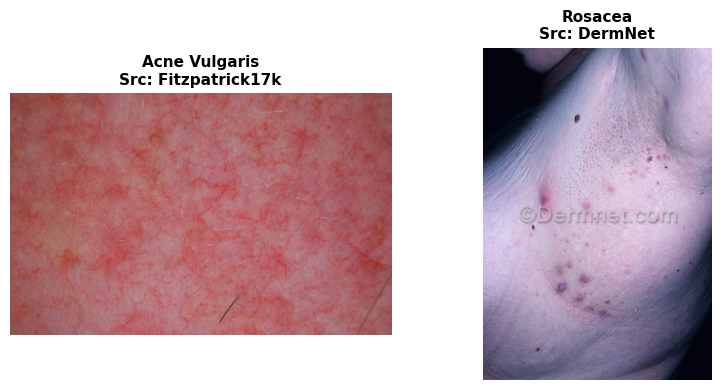


  SUPER-CLASS: BENIGN (2 specific diseases)


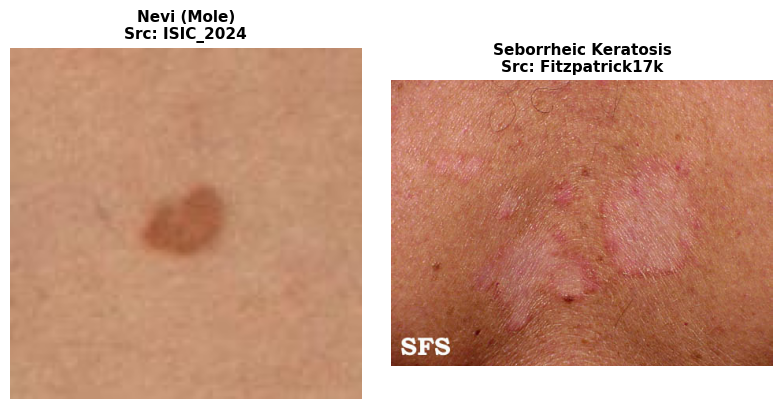


  SUPER-CLASS: HAIR_NAIL (2 specific diseases)


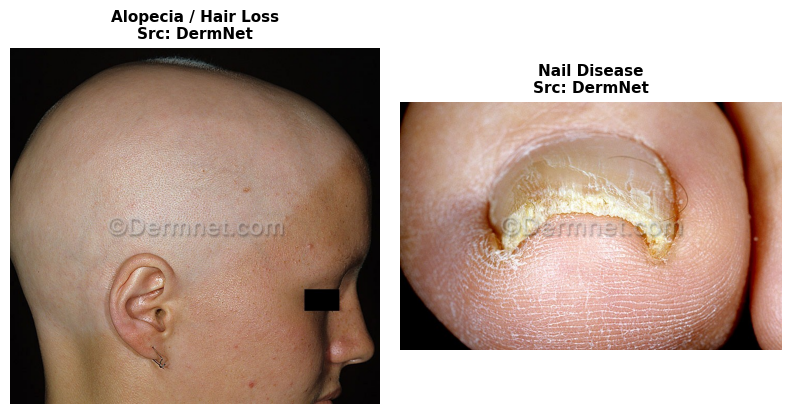


  SUPER-CLASS: INFECTIOUS (4 specific diseases)


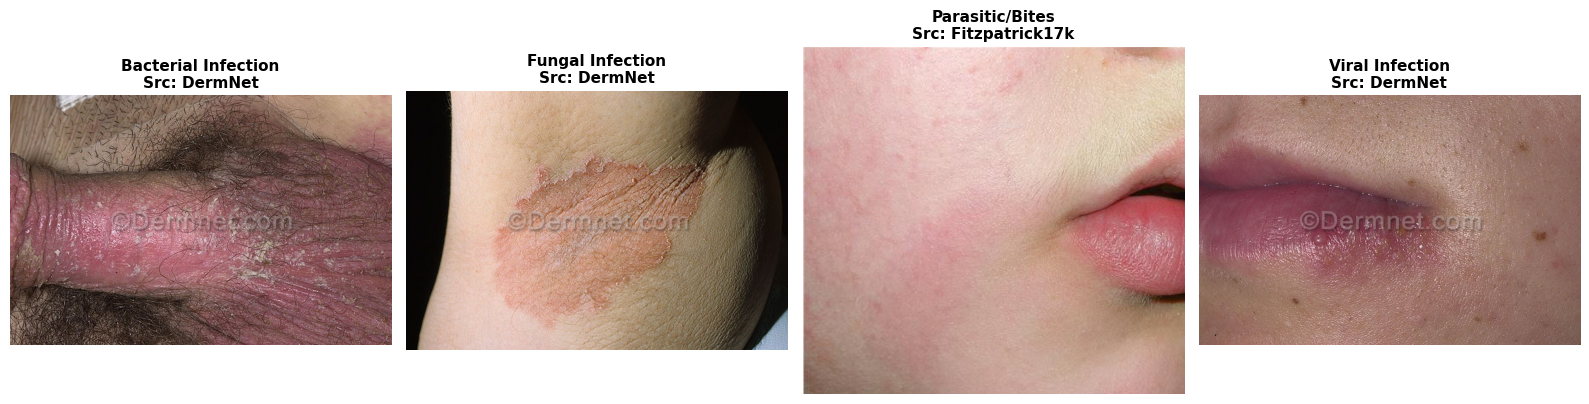


  SUPER-CLASS: INFLAMMATORY (6 specific diseases)


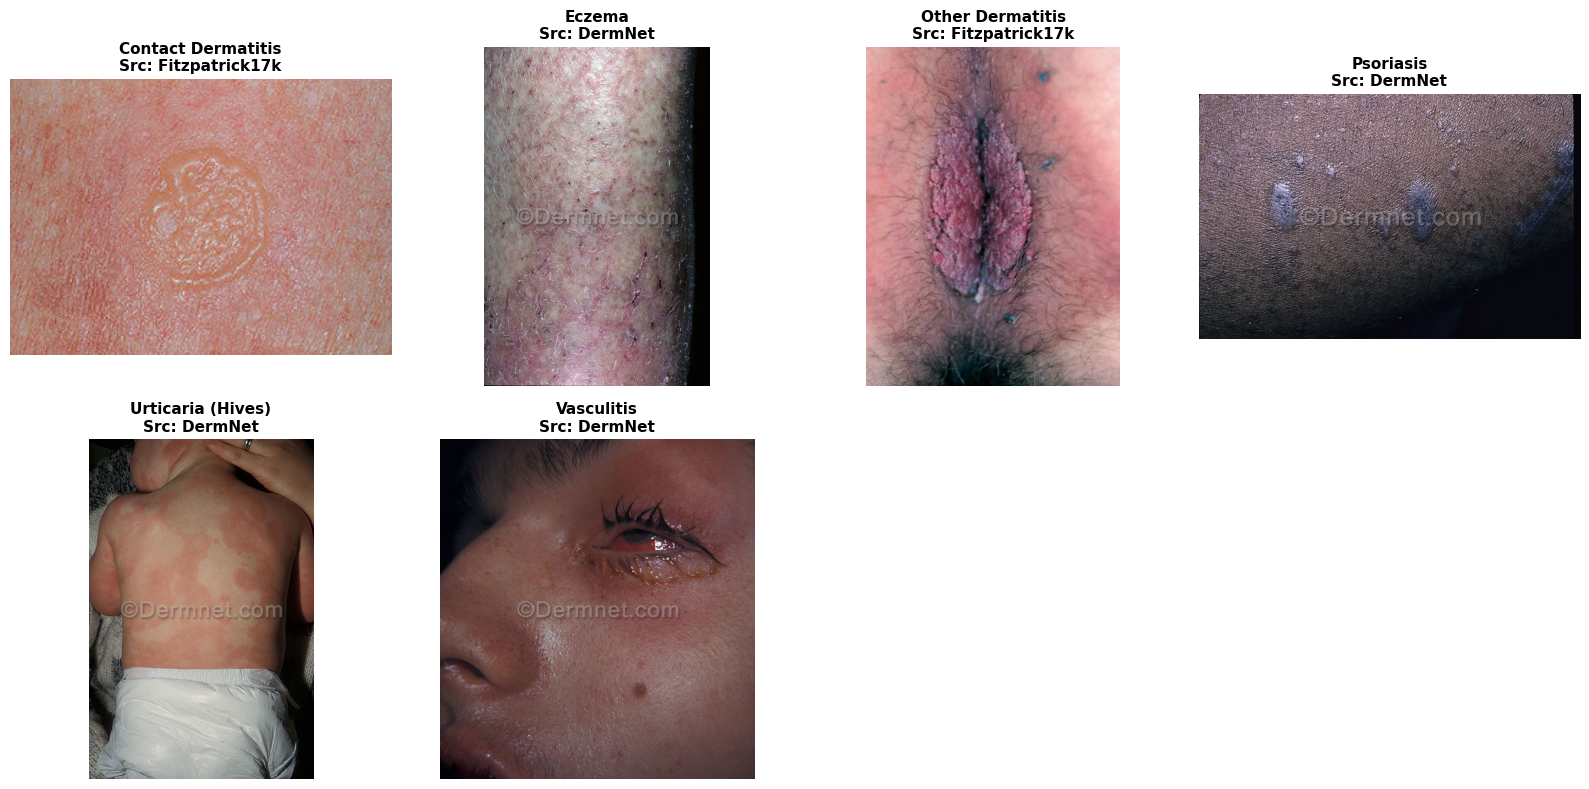


  SUPER-CLASS: MALIGNANT (4 specific diseases)


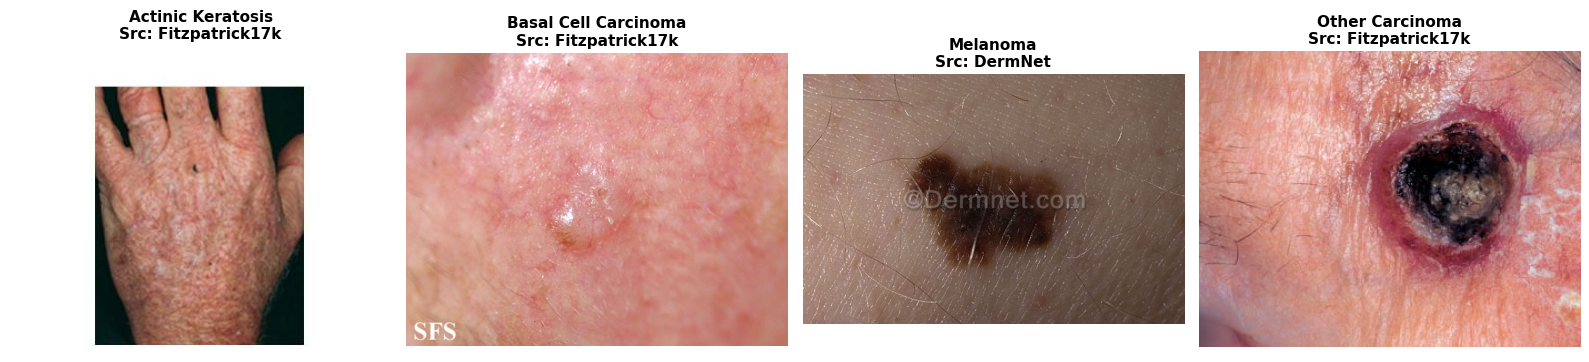


  SUPER-CLASS: PIGMENTARY (1 specific diseases)


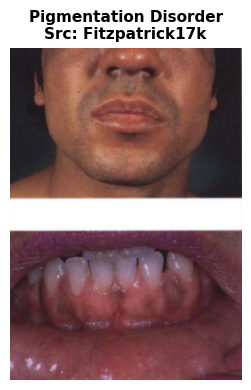


  SUPER-CLASS: SYSTEMIC_OTHER (6 specific diseases)


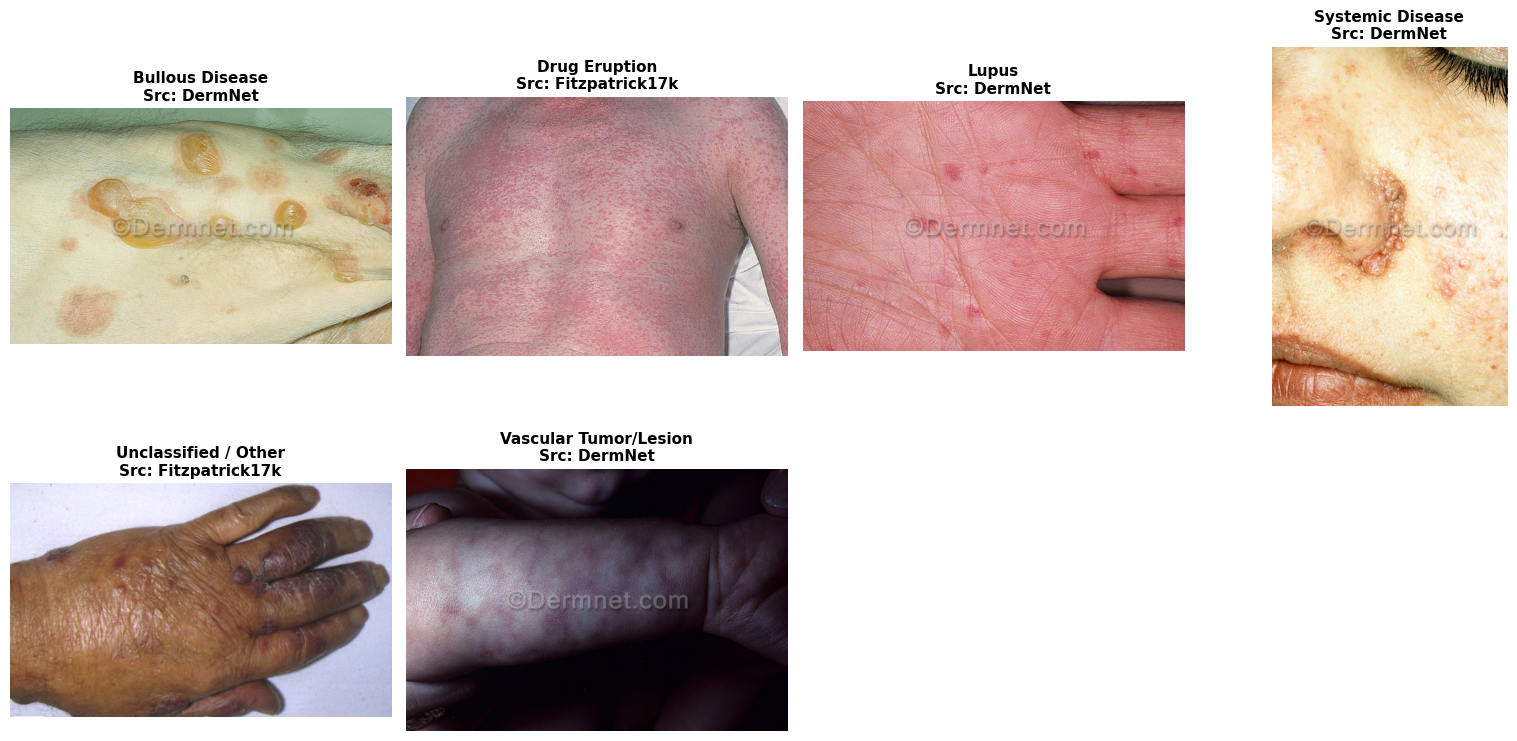

In [6]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def visualize_hierarchy(df):
    # Get all unique Super-Classes
    super_classes = sorted(df['super_class'].unique())
    
    for sc in super_classes:
        # Find all Sub-Classes that belong to this Super-Class
        sub_classes = sorted(df[df['super_class'] == sc]['sub_class'].unique())
        
        print(f"\n" + "="*50)
        print(f"  SUPER-CLASS: {sc.upper()} ({len(sub_classes)} specific diseases)")
        print("="*50)
        
        # Setup the grid based on how many sub-classes there are
        cols = 4
        rows = (len(sub_classes) // cols) + (1 if len(sub_classes) % cols > 0 else 0)
        plt.figure(figsize=(16, 4 * rows))
        
        for i, sub_c in enumerate(sub_classes):
            # Pick ONE random image from this exact sub-class
            sample_df = df[(df['super_class'] == sc) & (df['sub_class'] == sub_c)]
            
            if len(sample_df) > 0:
                sample = sample_df.sample(1).iloc[0]
                img_path = sample['image_path']
                source = sample['source']
                
                img = cv2.imread(img_path)
                plt.subplot(rows, cols, i + 1)
                
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    plt.imshow(img)
                    # Show the Sub-Class and where the image came from
                    plt.title(f"{sub_c}\nSrc: {source}", fontsize=11, fontweight='bold')
                else:
                    plt.imshow(np.zeros((224, 224, 3), dtype=np.uint8))
                    plt.title(f"Image Error\n{sub_c}", color='red')
                    
                plt.axis('off')
                
        plt.tight_layout()
        plt.show()

# Run it!
visualize_hierarchy(df_master)

In [7]:
import torch
import torch.nn as nn
import timm

class TwoTierSkinViT(nn.Module):
    def __init__(self, num_super_classes=8, num_sub_classes=25, pretrained=True):
        super(TwoTierSkinViT, self).__init__()
        
        # 1. The Backbone (The "Eyes")
        # We load the base ViT and remove its final classification layer (num_classes=0)
        self.backbone = timm.create_model(
            'vit_base_patch16_224', 
            pretrained=pretrained, 
            num_classes=0 
        )
        
        # Get the feature dimension size of the ViT (for vit_base, it's 768)
        self.embed_dim = self.backbone.num_features
        
        # 2. Tier 1 Head: Super-Class Predictor
        self.head_super = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(self.embed_dim, 256),
            nn.ReLU(),
            nn.Linear(256, num_super_classes)
        )
        
        # 3. Tier 2 Head: Sub-Class Predictor
        self.head_sub = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(self.embed_dim, 512),
            nn.ReLU(),
            nn.Linear(512, num_sub_classes)
        )

    def forward(self, x):
        # Extract features from the image using the ViT backbone
        features = self.backbone(x)
        
        # Pass the same features through both heads simultaneously
        out_super = self.head_super(features)
        out_sub = self.head_sub(features)
        
        return out_super, out_sub

# --- Initialize the Model ---
# Note: Update num_sub_classes to exactly match how many unique sub_classes you have in your CSV
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_super = len(df_master['super_class'].unique())
num_sub = len(df_master['sub_class'].unique())

model = TwoTierSkinViT(num_super_classes=num_super, num_sub_classes=num_sub)
model = model.to(device)

print(f"Multi-Task ViT Built! \nSuper-Classes: {num_super} | Sub-Classes: {num_sub}")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Multi-Task ViT Built! 
Super-Classes: 8 | Sub-Classes: 27


In [8]:
from torch.utils.data import Dataset
import cv2

class MultiTaskSkinDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
        
        # Create numerical mappings for both tiers
        self.super_classes = sorted(self.df['super_class'].unique())
        self.sub_classes = sorted(self.df['sub_class'].unique())
        
        self.super2idx = {name: i for i, name in enumerate(self.super_classes)}
        self.sub2idx = {name: i for i, name in enumerate(self.sub_classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Get image
        image = cv2.imread(row['image_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
            
        # Get BOTH labels
        label_super = self.super2idx[row['super_class']]
        label_sub = self.sub2idx[row['sub_class']]
        
        return image, torch.tensor(label_super, dtype=torch.long), torch.tensor(label_sub, dtype=torch.long)

In [9]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Training transform (with augmentations)
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Validation transform (no augmentations, just resize + normalize)
val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [10]:
from torch.utils.data import DataLoader

# 1. Split the Master Dataframe (80% for training, 20% for testing)
# We use random_state so it splits exactly the same way every time you run it
train_df = df_master.sample(frac=0.8, random_state=42)
val_df = df_master.drop(train_df.index)

# 2. Build the actual Dataset Objects using your blueprint
# (Assuming 'train_transform' and 'val_transform' from our Albumentations step are still in memory)
train_dataset = MultiTaskSkinDataset(train_df, transform=train_transform)
val_dataset = MultiTaskSkinDataset(val_df, transform=val_transform)

# 3. Create DataLoaders (The "Conveyor Belts" that feed the ViT model)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# 4. Print confirmation so we know it worked!
print("=== DATALOADERS READY ===")
print(f"Training Images: {len(train_dataset)}")
print(f"Validation Images: {len(val_dataset)}")
print(f"Number of Super-Classes: {len(train_dataset.super_classes)}")
print(f"Number of Sub-Classes: {len(train_dataset.sub_classes)}")

=== DATALOADERS READY ===
Training Images: 34019
Validation Images: 8505
Number of Super-Classes: 8
Number of Sub-Classes: 27


In [11]:
# Grab ONE batch from the conveyor belt
sample_images, sample_super_labels, sample_sub_labels = next(iter(train_loader))

print("\n=== BATCH TEST ===")
print(f"Image Batch Shape: {sample_images.shape}") # Should be [32, 3, 224, 224]
print(f"Super-Class Labels Shape: {sample_super_labels.shape}") # Should be [32]
print(f"Sub-Class Labels Shape: {sample_sub_labels.shape}") # Should be [32]

# Let's see what the very first image in the batch is labeled as:
super_idx = sample_super_labels[0].item()
sub_idx = sample_sub_labels[0].item()

print(f"\nFirst Image in Batch is labeled as:")
print(f"Tier 1 (Super): {train_dataset.super_classes[super_idx]}")
print(f"Tier 2 (Sub): {train_dataset.sub_classes[sub_idx]}")


=== BATCH TEST ===
Image Batch Shape: torch.Size([32, 3, 224, 224])
Super-Class Labels Shape: torch.Size([32])
Sub-Class Labels Shape: torch.Size([32])

First Image in Batch is labeled as:
Tier 1 (Super): Benign
Tier 2 (Sub): Nevi (Mole)


In [12]:
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm
import logging

# --- 0. CONFIGURE LOGGING ---
logging.basicConfig(
    filename='/kaggle/working/training.log',  # log file saved in Kaggle output
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logging.info("🔥 Starting the Multi-Task Training Engine...")

# --- 1. SETUP THE ENGINE ---
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

criterion_super = nn.CrossEntropyLoss()
criterion_sub = nn.CrossEntropyLoss()

scaler = GradScaler()
epochs = 5  # Adjust based on Kaggle session limits

print("🔥 Starting the Multi-Task Training Engine...")

# --- 2. TRAINING LOOP ---
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    
    for images, labels_super, labels_sub in loop:
        images = images.to(device)
        labels_super = labels_super.to(device)
        labels_sub = labels_sub.to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            preds_super, preds_sub = model(images)
            loss_super = criterion_super(preds_super, labels_super)
            loss_sub = criterion_sub(preds_sub, labels_sub)
            total_loss = loss_super + loss_sub
        
        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += total_loss.item()
        
        loop.set_postfix(
            loss=total_loss.item(),
            super_L=loss_super.item(),
            sub_L=loss_sub.item()
        )
        
        # Log batch-level metrics
        logging.info(
            f"Epoch {epoch+1}, Batch Loss={total_loss.item():.4f}, "
            f"Super={loss_super.item():.4f}, Sub={loss_sub.item():.4f}"
        )
    
    avg_loss = running_loss / len(train_loader)
    print(f"\n✅ Epoch {epoch+1} Completed | Average Total Loss: {avg_loss:.4f}")
    logging.info(f"Epoch {epoch+1} Completed | Average Total Loss: {avg_loss:.4f}")
    
    # Save checkpoint
    model_path = f"/kaggle/working/world_class_vit_epoch_{epoch+1}.pth"
    torch.save(model.state_dict(), model_path)
    print(f"💾 Model Saved: {model_path}\n" + "-"*50)
    logging.info(f"💾 Model Saved: {model_path}")

/tmp/ipykernel_55/3247827878.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


🔥 Starting the Multi-Task Training Engine...


Epoch 1/5:   0%|          | 0/1064 [00:00<?, ?it/s]/tmp/ipykernel_55/3247827878.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/5: 100%|██████████| 1064/1064 [06:30<00:00,  2.72it/s, loss=2.71, sub_L=1.78, super_L=0.929]



✅ Epoch 1 Completed | Average Total Loss: 2.6295
💾 Model Saved: world_class_vit_epoch_1.pth
--------------------------------------------------


Epoch 2/5: 100%|██████████| 1064/1064 [05:16<00:00,  3.36it/s, loss=1.01, sub_L=0.732, super_L=0.282]


...


✅ Epoch 3 Completed | Average Total Loss: 1.7438
💾 Model Saved: world_class_vit_epoch_3.pth
--------------------------------------------------


Epoch 4/5: 100%|██████████| 1064/1064 [05:16<00:00,  3.36it/s, loss=2.81, sub_L=1.26, super_L=1.55]   



✅ Epoch 4 Completed | Average Total Loss: 1.4257
💾 Model Saved: world_class_vit_epoch_4.pth
--------------------------------------------------


Epoch 5/5: 100%|██████████| 1064/1064 [05:16<00:00,  3.37it/s, loss=1.19, sub_L=0.581, super_L=0.608] 



✅ Epoch 5 Completed | Average Total Loss: 1.1229
💾 Model Saved: world_class_vit_epoch_5.pth
--------------------------------------------------


Testing Image: /kaggle/input/fitzpatrick17k-original/finalfitz17k/f1bdfe975f053e9b464b14f555db1aec.jpg
True Labels -> Tier 1: Malignant | Tier 2: Melanoma



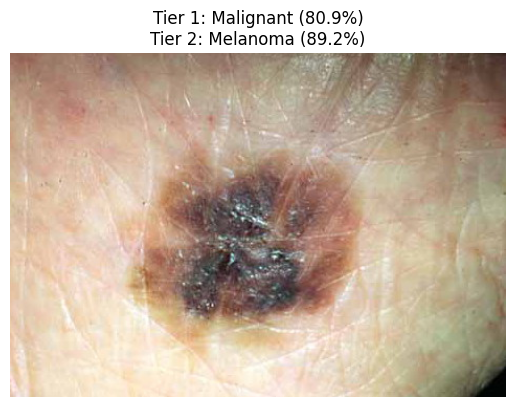

=== AI JSON OUTPUT ===
{
    "tier_1_category": "Malignant",
    "tier_1_confidence": 80.94,
    "tier_2_disease": "Melanoma",
    "tier_2_confidence": 89.23,
    "status": "Ready for LLM Processing"
}


In [20]:
  import torch
import cv2
import numpy as np
import json
import matplotlib.pyplot as plt

# 1. Setup Device and Load the Saved Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate the blueprint (make sure num_classes matches your training!)
trained_model = TwoTierSkinViT(
    num_super_classes=len(train_dataset.super_classes), 
    num_sub_classes=len(train_dataset.sub_classes), 
    pretrained=False # We don't need to download the base again
)

# Load your winning weights
trained_model.load_state_dict(torch.load('world_class_vit_epoch_5.pth', map_location=device))
trained_model.to(device)
trained_model.eval() # Set to evaluation mode

# 2. The Analysis Engine
def analyze_real_world_image(image_path, model, dataset):
    # Load and Preprocess Image
    img = cv2.imread(image_path)
    if img is None:
        return "Image not found."
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # ... inside your analyze_real_world_image function ...
    
    # Resize and Normalize exactly like Albumentations does
    img_resized = cv2.resize(img_rgb, (224, 224))
    
    # FIX: Force float32 here
    img_normalized = img_resized.astype(np.float32) / 255.0 
    
    # FIX: Ensure the mean/std are also float32
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img_normalized = (img_normalized - mean) / std
    
    # Convert to Tensor (PyTorch will automatically make it torch.float32 now)
    img_tensor = torch.tensor(img_normalized).permute(2, 0, 1).unsqueeze(0).to(device)
    
    # ... rest of the function ...
    
    
    # Get Predictions
    with torch.no_grad():
        out_super, out_sub = model(img_tensor)
        
        # Convert raw scores to percentages (Softmax)
        probs_super = torch.nn.functional.softmax(out_super[0], dim=0)
        probs_sub = torch.nn.functional.softmax(out_sub[0], dim=0)
        
    # Find the top guess for Tier 1
    conf_super, idx_super = torch.max(probs_super, 0)
    pred_super = dataset.super_classes[idx_super.item()]
    
    # Find the top guess for Tier 2
    conf_sub, idx_sub = torch.max(probs_sub, 0)
    pred_sub = dataset.sub_classes[idx_sub.item()]
    
    # Visualize
    plt.imshow(img_rgb)
    plt.title(f"Tier 1: {pred_super} ({conf_super.item()*100:.1f}%)\nTier 2: {pred_sub} ({conf_sub.item()*100:.1f}%)")
    plt.axis('off')
    plt.show()
    
    # Format the Output JSON for the LLM
    output_data = {
        "tier_1_category": pred_super,
        "tier_1_confidence": round(conf_super.item() * 100, 2),
        "tier_2_disease": pred_sub,
        "tier_2_confidence": round(conf_sub.item() * 100, 2),
        "status": "Ready for LLM Processing"
    }
    
    return json.dumps(output_data, indent=4)

# 3. Test it on a random validation image!
test_row = val_df.sample(1).iloc[0]
print(f"Testing Image: {test_row['image_path']}")
print(f"True Labels -> Tier 1: {test_row['super_class']} | Tier 2: {test_row['sub_class']}\n")

json_result = analyze_real_world_image(test_row['image_path'], trained_model, train_dataset)
print("=== AI JSON OUTPUT ===")
print(json_result)